# Modélisation des Valeurs Résiduelles : Nexialog x MoSEF
**Objectif :** Prédire le prix de revente (valeur résiduelle) de véhicules Renault/Dacia/Nissan à la fin de leurs contrats de leasing, à partir de transactions historiques sur le marché allemand.


## Imports & Chargement des données

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# Sklearn
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler, OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Gradient Boosting
from xgboost import XGBRegressor
import lightgbm as lgb

# SHAP
import shap

# Config affichage
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# Chemins
DATA_DIR         = Path('.')
USED_MARKET_PATH = DATA_DIR / 'used_market.xlsb'
PORTFOLIO_PATH   = DATA_DIR / 'portfolio.xlsx'
USED_MARKET_CSV  = DATA_DIR / 'used_market.csv'   # cache CSV pour relecture rapide
OUTPUT_CSV       = DATA_DIR / 'predictions.csv'

# Fonctions utilitaires
from utils_fonction import load_data

In [11]:
mkt, pf = load_data(
    used_market_path=USED_MARKET_PATH,
    portfolio_path=PORTFOLIO_PATH,
)

[used_market] Lecture cache CSV : used_market.csv
[used_market] 736,958 lignes x 22 colonnes
[portfolio]   1,951 lignes x 19 colonnes


In [ ]:
# Used Market  
display(mkt.head(3))
print('\nColonnes :', list(mkt.columns))

,country_code,brand,MODEL,MARK / Generation,Phase (Facelift),RANGE TYPE,FUEL TYPE,Engine Power (HP),gearbox,BODY TYPE,MODEL SEGMENT,grouping,modelyear,productionYear,id_group,id,date de vente,mileage,age,prix de vente,prix catalogue d'origine,sample size
0,DE,DACIA,LOGAN,1,1,PC,PETROL,74,Manual,SEDAN,B,"LOGAN, Limousine, Doors=4, Super, 55kW, M, 200...",2005,2005,242,242,43115,75000,120,1113,6675,1
1,DE,DACIA,LOGAN,1,1,PC,PETROL,74,Manual,SEDAN,B,"LOGAN, Limousine, Doors=4, Super, 55kW, M, 200...",2005,2005,242,242,43174,30000,108,1476,7055,1
2,DE,DACIA,LOGAN,1,1,PC,PETROL,74,Manual,SEDAN,B,"LOGAN, Limousine, Doors=4, Super, 55kW, M, 200...",2005,2005,242,242,43174,75000,120,992,6449,1



Colonnes : ['country_code', 'brand', 'MODEL', 'MARK / Generation', 'Phase (Facelift)', 'RANGE TYPE', 'FUEL TYPE', 'Engine Power (HP)', 'gearbox', 'BODY TYPE', 'MODEL SEGMENT', 'grouping', 'modelyear', 'productionYear', 'id_group', 'id', 'date de vente', 'mileage', 'age', 'prix de vente', "prix catalogue d'origine", 'sample size']


In [6]:
# Portfolio 
display(pf.head(3))
print('\nColonnes :', list(pf.columns))

,id,country_name,produit financier,version_name,brand,model,production_year,fuel_type,range_type,contract_start_date,current_contract_planned_end_date,contract_start_year,contract_end_year,contract_duration,remaining_contract_duration,contract_mileage,initial_car_age,initial_mileage,prix catalogue d'origine
0,1,Germany,OPERATIONAL LEASE,ADVANCE L1 TCE 100 FAP,RENAULT,KANGOO,2021,PETROL,LCV,2022-04-26,2026-04-25,2022,2026,48,3,50042,0,0,19440.00
1,2,Germany,OPERATIONAL LEASE,BLACK EDITION TCE 140 EDC GPF,RENAULT,SCENIC,2020,PETROL,PC,2021-02-27,2026-02-26,2021,2026,60,1,50025,0,0,30000.00
2,3,Germany,OPERATIONAL LEASE,BUSINESS EDITION TCE 90 (MY21),RENAULT,CLIO,2021,PETROL,PC,2023-01-17,2026-01-16,2023,2026,36,0,30023,1,45,15924.37



Colonnes : ['id', 'country_name', 'produit financier', 'version_name', 'brand', 'model', 'production_year', 'fuel_type', 'range_type', 'contract_start_date', 'current_contract_planned_end_date', 'contract_start_year', 'contract_end_year', 'contract_duration', 'remaining_contract_duration', 'contract_mileage', 'initial_car_age', 'initial_mileage', "prix catalogue d'origine"]


In [ ]:
# Renommage et Nettoyage du Used Market

from src.utils_fonction import clean_used_market

mkt = clean_used_market(mkt)

Lignes supprimées (sale_price NaN) : 0
used_market après nettoyage : (736958, 22)


,country_code,brand,model,MARK / Generation,Phase (Facelift),range_type,fuel_type,Engine Power (HP),gearbox,body_type,model_segment,grouping,model_year,production_year,id_group,id,sale_date,mileage,age_months,sale_price,list_price,sample size
dtype,str,str,str,int64,int64,str,str,int64,str,str,str,str,int64,int64,int64,int64,datetime64[s],int64,int64,int64,int64,int64


In [14]:
# Renommage et Nettoyage du Portfolio
from src.utils_fonction import clean_portfolio

pf = clean_portfolio(pf)

portfolio après nettoyage : (1951, 19)


,id,country_name,produit financier,version_name,brand,model,production_year,fuel_type,range_type,contract_start_date,end_date,contract_start_year,contract_end_year,contract_duration,remaining_duration,contract_mileage,initial_age,initial_mileage,list_price
dtype,int64,str,str,str,str,str,int64,str,str,datetime64[us],datetime64[us],int64,int64,int64,int64,int64,int64,int64,float64


##  Analyse Exploratoire (EDA)
#### 2.1 Statistiques descriptives de la variable cible 

=== Statistiques sale_price (prix de vente) ===


,count,mean,std,min,25%,50%,75%,max
sale_price,736958.00,10293.85,6157.33,362.00,5939.00,9063.00,13192.00,117236.00


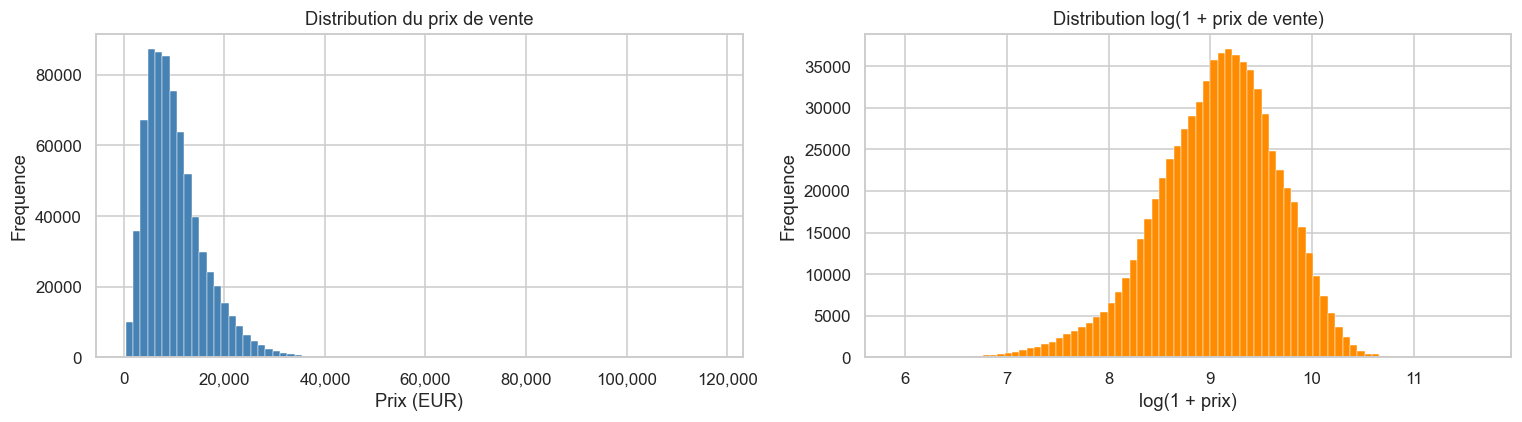

In [17]:
print('=== Statistiques sale_price (prix de vente) ===')
display(mkt['sale_price'].describe().to_frame().T)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(mkt['sale_price'], bins=80, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].set_title('Distribution du prix de vente')
axes[0].set_xlabel('Prix (EUR)')
axes[0].set_ylabel('Frequence')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].hist(np.log1p(mkt['sale_price']), bins=80, color='darkorange', edgecolor='white', linewidth=0.3)
axes[1].set_title('Distribution log(1 + prix de vente)')
axes[1].set_xlabel('log(1 + prix)')
axes[1].set_ylabel('Frequence')

plt.tight_layout()
plt.show()

**Distribution brute (gauche)**

La distribution est fortement asymétrique à droite : la majorité des
transactions se concentre entre 2 000 et 15 000 €, avec un pic autour de
5 000-8 000 €, puis une longue queue vers les prix élevés jusqu'à 120 000 €.
Cette asymétrie est classique sur les données de prix et cela risque de pénaliser les modèles
linéaires qui supposent une distribution symétrique des résidus.

**Distribution log-transformée (droite)**

Après transformation log(1 + prix), la distribution devient quasi-symétrique
et proche d'une gaussienne, centrée autour de 9 (soit e^9 ~ 8 100 €). C'est
une très bonne nouvelle pour la modélisation.

#### 2.2 Repartition par marque, carburant, segment 

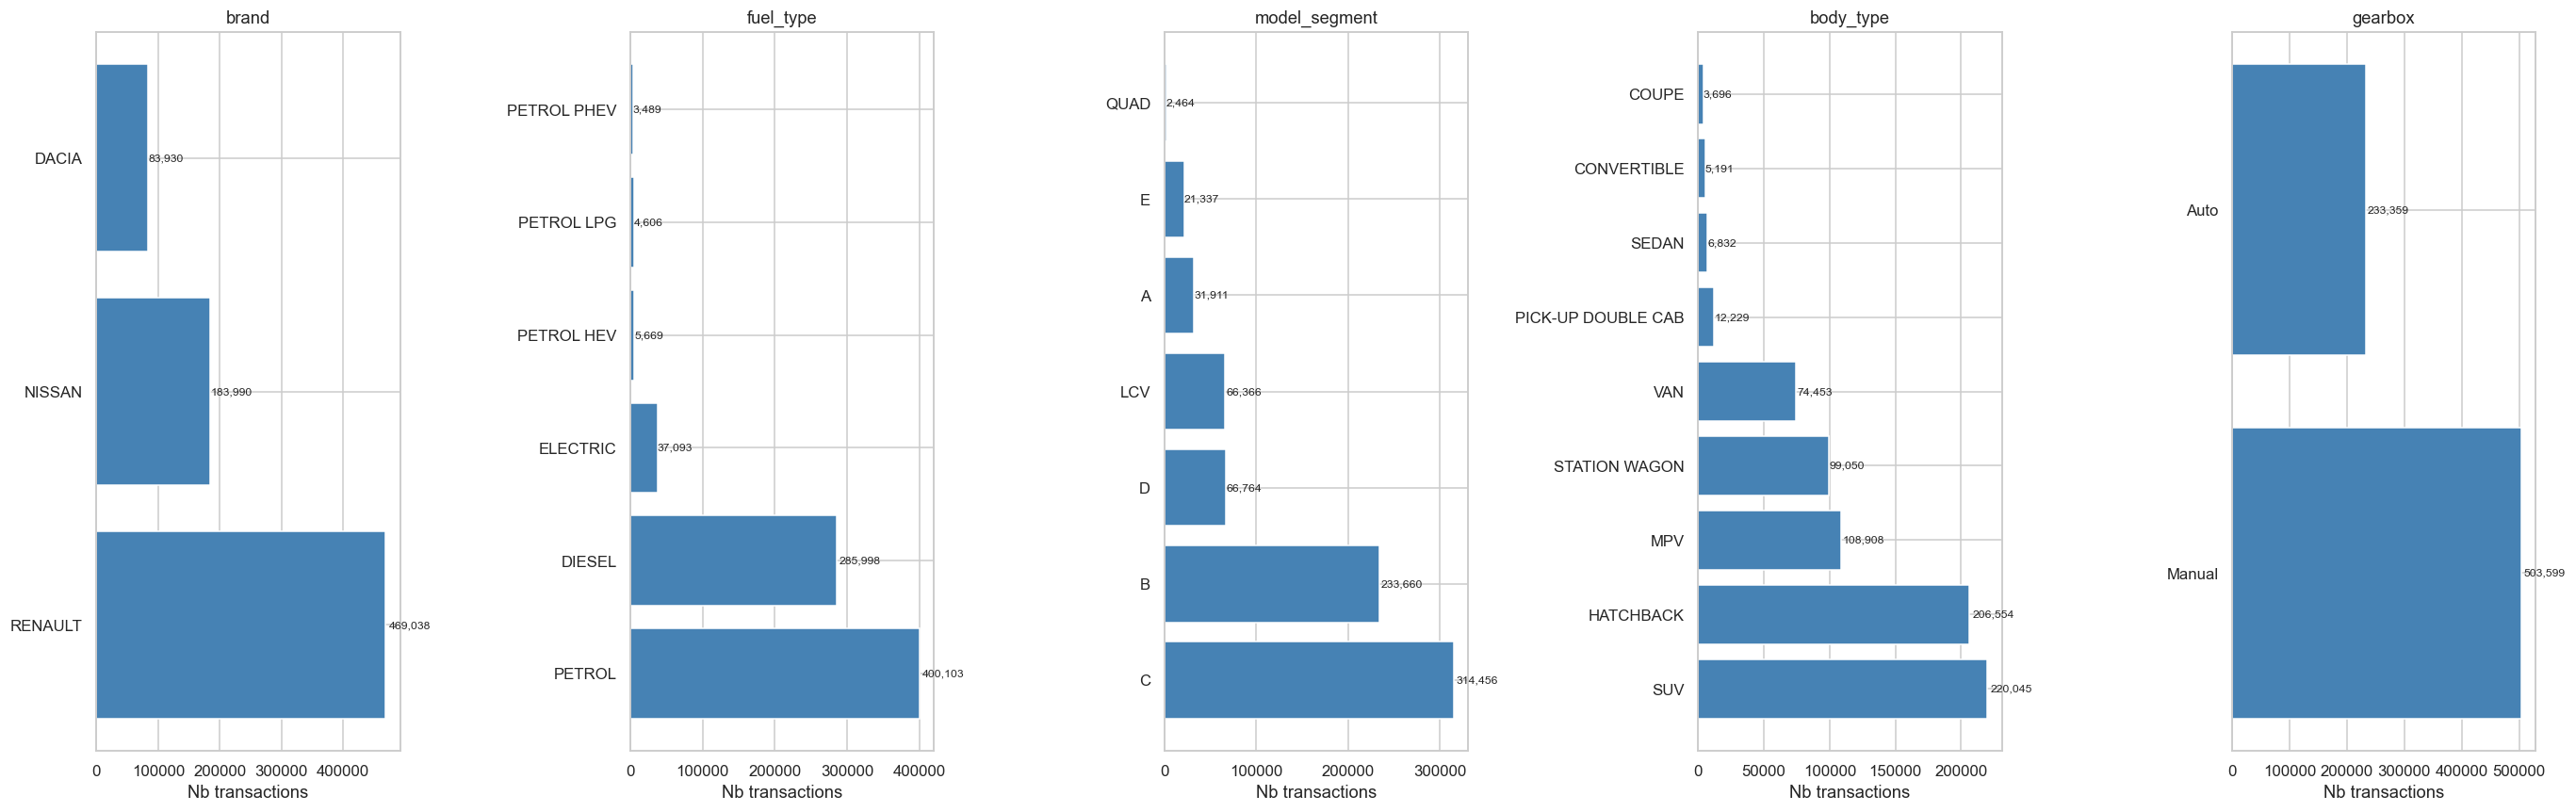

In [16]:
cat_cols = [c for c in ['brand', 'fuel_type', 'model_segment', 'body_type', 'gearbox'] if c in mkt.columns]
n = len(cat_cols)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 8))
if n == 1:
    axes = [axes]

for ax, col in zip(axes, cat_cols):
    counts = mkt[col].value_counts()
    ax.barh(counts.index, counts.values, color='steelblue')
    ax.set_title(col)
    ax.set_xlabel('Nb transactions')
    for i, v in enumerate(counts.values):
        ax.text(v * 1.01, i, f'{v:,}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

**Marque (brand)**

Renault domine largement avec 469 038 transactions, soit environ 64% du dataset.
Nissan représente 184 000 transactions et Dacia 84 000. Ce déséquilibre est
important : le modèle sera naturellement mieux calibré sur Renault que sur
les deux autres marques.

**Type de carburant (fuel_type)**

Petrol (400k) et Diesel (286k) représentent ensemble plus de 90% des transactions.
Les motorisations alternatives (Electric, HEV, PHEV, LPG) sont très minoritaires
avec moins de 40 000 observations chacune. La faible représentation de l'électrique
(37 093) est une limite directe pour prédire les véhicules électriques du portfolio.

**Segment (model_segment)**

Le segment C domine (314k), suivi du segment B (234k). Les segments premium
(E, QUAD) et les utilitaires (LCV) sont bien moins représentés. Le segment D
et LCV ont des volumes comparables autour de 66 000 transactions.

**Carrosserie (body_type)**

SUV (220k) et Hatchback (207k) sont les plus représentés, ce qui reflète
l'évolution du marché automobile européen vers les SUV ces dernières années.
MPV, Station Wagon et VAN complètent le tableau. Les Coupés et Cabriolets
sont anecdotiques dans ce dataset orienté marques généralistes.

**Boîte de vitesses (gearbox)**

La boîte manuelle domine nettement (504k vs 233k pour l'automatique), ce qui
est cohérent avec le marché allemand de l'occasion sur la période 2018-2025,
bien que la tendance soit à la progression de l'automatique sur les années
récentes.

####  2.3 Courbes de depreciation par type de carburant: prix median par tranche d'age 

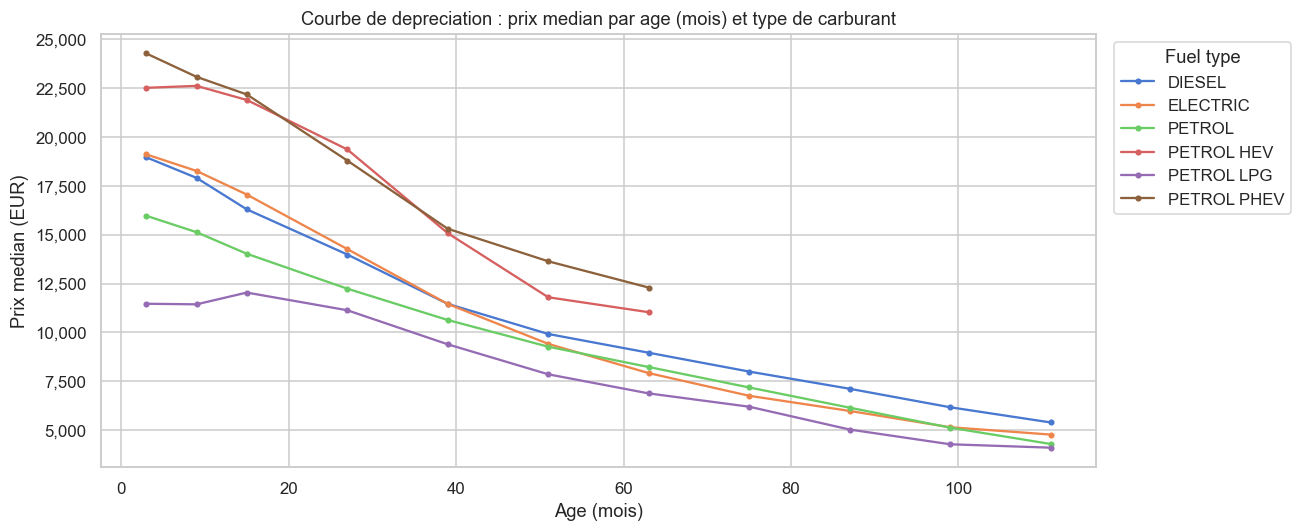

In [40]:
q_low  = mkt['sale_price'].quantile(0.01)
q_high = mkt['sale_price'].quantile(0.99)
mkt_viz = mkt[(mkt['sale_price'] >= q_low) & (mkt['sale_price'] <= q_high)].copy()

if 'age_months' in mkt_viz.columns and 'fuel_type' in mkt_viz.columns:
    mkt_viz['age_bin'] = pd.cut(mkt_viz['age_months'], bins=range(0, 120, 6), right=False)
    dep = (
        mkt_viz.groupby(['age_bin', 'fuel_type'], observed=True)['sale_price']
        .median()
        .reset_index()
    )
    dep['age_mid'] = dep['age_bin'].apply(lambda x: x.mid if pd.notna(x) else np.nan)

    fig, ax = plt.subplots(figsize=(12, 5))
    for ft, grp in dep.groupby('fuel_type'):
        ax.plot(grp['age_mid'], grp['sale_price'], marker='o', markersize=3, label=ft)
    ax.set_title('Courbe de depreciation : prix median par age (mois) et type de carburant')
    ax.set_xlabel('Age (mois)')
    ax.set_ylabel('Prix median (EUR)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.legend(title='Fuel type', bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

**PETROL PHEV** démarre le plus haut (~24 000 €) et se déprécie très rapidement
jusqu'à 40 mois, signe d'un prix catalogue élevé et d'une forte décote initiale
liée à l'évolution rapide de la technologie hybride rechargeable.

**PETROL HEV** suit une trajectoire similaire mais part de ~22 500 € et se stabilise
davantage après 60 mois, ce qui suggère une meilleure rétention de valeur à long
terme que le PHEV.

**DIESEL** et **ELECTRIC** partent de niveaux proches (~19 000 €) mais divergent
progressivement : l'électrique conserve légèrement mieux sa valeur jusqu'à 60 mois,
avant de rejoindre le diesel autour de 8 000 € à 100 mois. Ce résultat est à
interpréter avec prudence car les données électriques sont moins denses sur les
véhicules âgés (peu de recul historique).

**PETROL** affiche la dépréciation la plus régulière et prévisible, ce qui en fait
une bonne référence pour la modélisation.

**PETROL LPG** présente un comportement atypique entre 0 et 20 mois (courbe plate
voire légèrement croissante), probablement dû à un faible volume de transactions
sur les véhicules jeunes — à surveiller lors du feature engineering.

> **Point d'attention** : les courbes ne sont pas linéaires.
> Une régression Ridge/Lasso devra intégrer `age_months²` ou une transformation
> log du prix pour capturer la convexité. XGBoost/LightGBM la capturera
> naturellement.

#### 2.4 Courbes de depreciation par marque 

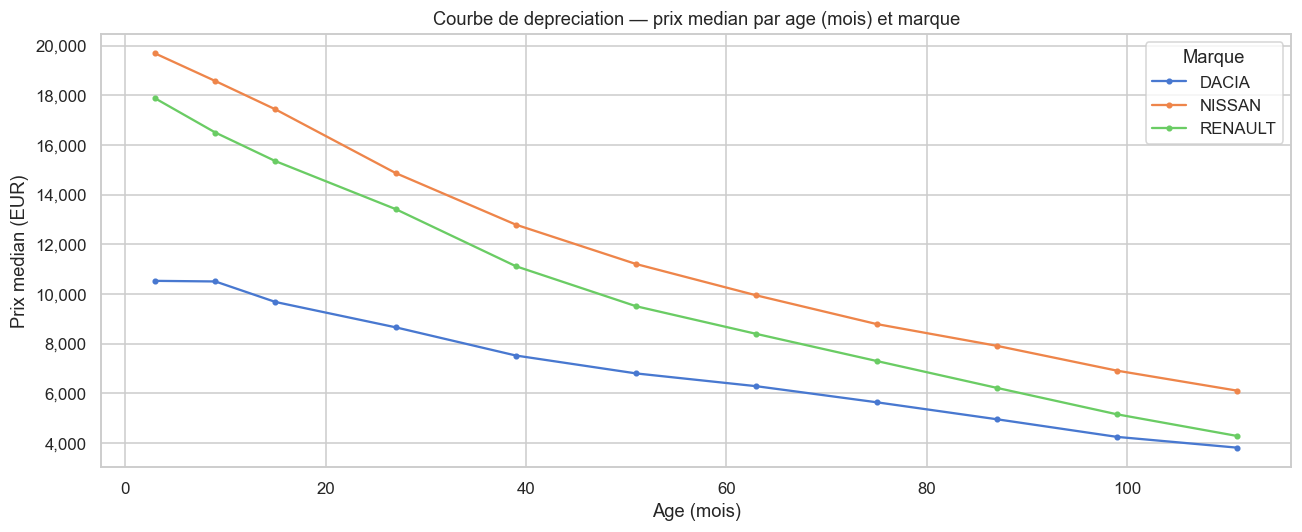

In [20]:
if 'age_months' in mkt_viz.columns and 'brand' in mkt_viz.columns:
    dep_brand = (
        mkt_viz.groupby(['age_bin', 'brand'], observed=True)['sale_price']
        .median()
        .reset_index()
    )
    dep_brand['age_mid'] = dep_brand['age_bin'].apply(lambda x: x.mid if pd.notna(x) else np.nan)

    fig, ax = plt.subplots(figsize=(12, 5))
    for brand, grp in dep_brand.groupby('brand'):
        ax.plot(grp['age_mid'], grp['sale_price'], marker='o', markersize=3, label=brand)
    ax.set_title('Courbe de depreciation — prix median par age (mois) et marque')
    ax.set_xlabel('Age (mois)')
    ax.set_ylabel('Prix median (EUR)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.legend(title='Marque')
    plt.tight_layout()
    plt.show()

Les trois marques suivent une dépréciation régulière et quasi-linéaire sur
l'ensemble de la période, ce qui est une bonne nouvelle pour la modélisation.

**Nissan** part le plus haut (~20 000 €) et maintient l'écart avec les deux
autres marques tout au long de la vie du véhicule. Sa courbe reste au-dessus
même à 110 mois (~6 000 €), signe d'un meilleur maintien de valeur absolu.

**Renault** démarre à ~18 000 € et se déprécie de façon très parallèle à Nissan,
avec un écart quasi-constant d'environ 2 000 € sur toute la durée. Les deux
marques ont des profils de dépréciation structurellement similaires.

**Dacia** se distingue nettement : prix de départ bien plus bas (~10 500 €) et
courbe plus plate en valeur absolue. Elle perd moins d'euros mais proportionnellement
la dépréciation reste forte. C'est cohérent avec son positionnement entrée de gamme, les acheteurs d'occasion valorisent moins ces véhicules.

> **Point d'attention** : la marque est clairement un déterminant
> fort du prix. Elle devra être encodée comme feature catégorielle (one-hot ou
> target encoding). L'écart Dacia vs Nissan/Renault suggère aussi qu'un modèle
> entraîné toutes marques confondues devra bien capturer cet effet — à vérifier
> via les SHAP values.

#### 2.5 Correlations numeriques avec sale_price 

Correlation avec sale_price :


,sale_price
sale_price,1.00
list_price,0.79
Engine Power (HP),0.68
model_year,0.62
production_year,0.62
Phase (Facelift),0.19
sample size,0.14
id_group,0.13
id,0.13
MARK / Generation,0.08


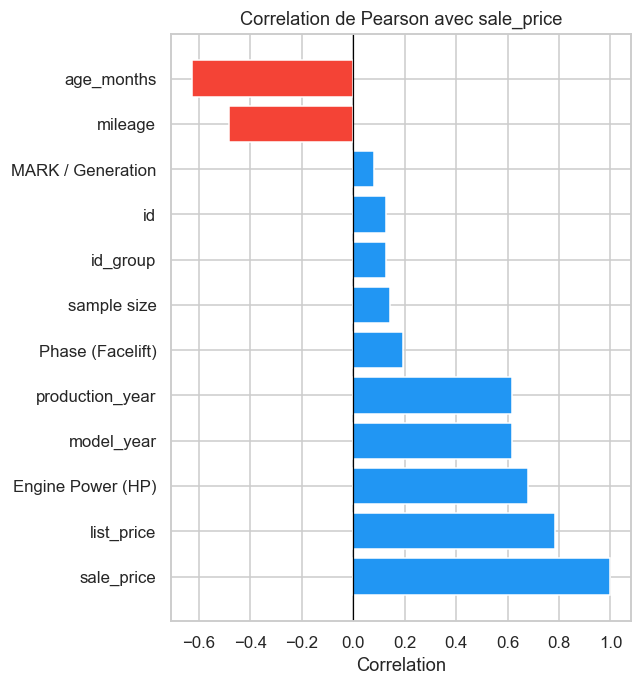

In [21]:
num_cols = mkt.select_dtypes(include='number').columns.tolist()
print('Correlation avec sale_price :')
corr = mkt[num_cols].corr()[['sale_price']].sort_values('sale_price', ascending=False)
display(corr)

fig, ax = plt.subplots(figsize=(6, len(num_cols) * 0.45 + 1))
colors = ['#2196F3' if v >= 0 else '#F44336' for v in corr['sale_price']]
ax.barh(corr.index, corr['sale_price'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlation de Pearson avec sale_price')
ax.set_xlabel('Correlation')
plt.tight_layout()
plt.show()

**Corrélations positives (le prix monte avec la variable)**

`list_price` (0.79) est la corrélation la plus forte, logique, le prix neuf
d'un véhicule conditionne fortement sa valeur de revente. Ce sera probablement
la feature la plus importante dans les modèles.

`Engine Power (0.68)`  plus le moteur est puissant, plus le véhicule se revend
cher. Capte indirectement le segment du véhicule (citadine vs SUV).

`model_year` et `production_year` (0.62 tous les deux), les véhicules récents
valent plus cher, ce qui est cohérent. Ces deux variables sont très corrélées
entre elles, attention à la **multicolinéarité** pour le modèle.

**Corrélations négatives (le prix baisse avec la variable)**

`age_months` (-0.63) plus le véhicule est vieux, moins il vaut. C'est le
moteur principal de la dépréciation, confirmé visuellement par les courbes 2.3
et 2.4.

`mileage` (-0.48) le kilométrage dégrade aussi la valeur, mais moins que l'âge
seul. Les deux sont liés (un vieux véhicule a généralement plus de km), à
surveiller via une matrice de corrélation complète.

**Variables à faible signal**

`Phase (Facelift)` (0.19), `id_group` (0.13), `id` (0.13) et `MARK / Generation`
(0.08) ont une corrélation très faible avec le prix. `id` et `id_group` sont des
identifiants techniques sans pouvoir prédictif réel **à exclure des features**.

> **Conclusion modélisation** : les 4 features numériques clés sont `list_price`,
> `engine_power`, `age_months` et `mileage`. Les variables catégorielles
> (marque, carburant, segment) non présentes ici viendront compléter ce signal
> une fois encodées.

#### 2.6 Scatter : age vs prix, colore par fuel_type 

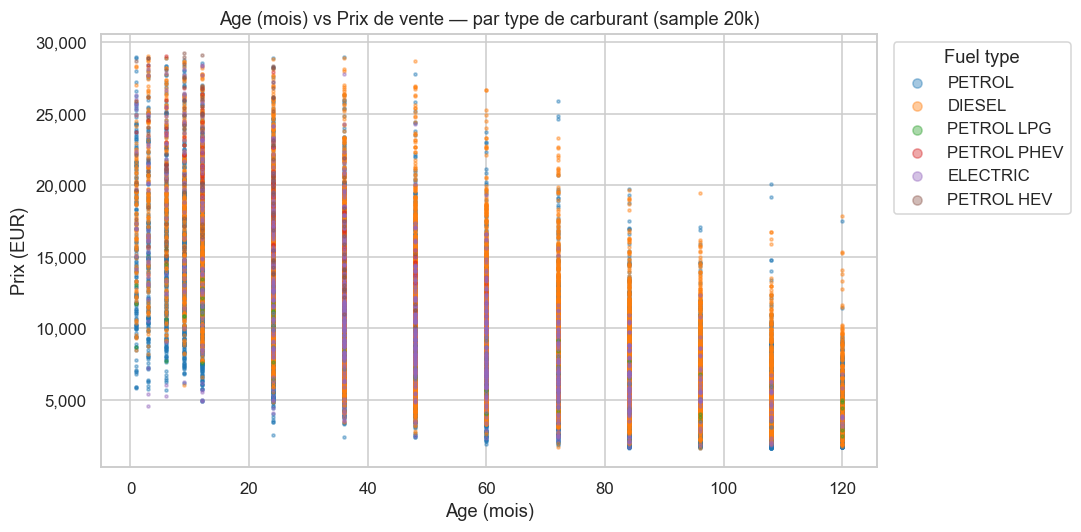

In [ ]:
if 'age_months' in mkt_viz.columns:
    sample = mkt_viz.sample(min(20_000, len(mkt_viz)), random_state=42)
    fuels = sample['fuel_type'].unique() if 'fuel_type' in sample.columns else []
    palette = sns.color_palette('tab10', len(fuels))
    color_map = dict(zip(fuels, palette))

    fig, ax = plt.subplots(figsize=(10, 5))
    for ft in fuels:
        sub = sample[sample['fuel_type'] == ft]
        ax.scatter(sub['age_months'], sub['sale_price'],
                   s=4, alpha=0.4, color=color_map[ft], label=ft)
    ax.set_title('Age (mois) vs Prix de vente par type de carburant (sample 20k)')
    ax.set_xlabel('Age (mois)')
    ax.set_ylabel('Prix (EUR)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.legend(title='Fuel type', markerscale=3, bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

Le premier constat frappant est la structure en colonnes verticales : les points
se regroupent sur des valeurs d'âge discrètes (0, 6, 12, 24, 36...) plutôt que
de se répartir continûment. Cela reflète la façon dont les données sont
collectées ou agrégées dans used_market, par tranches mensuelles fixes.

La dispersion verticale des prix est très large pour les véhicules jeunes
(0-12 mois) et se resserre progressivement avec l'âge. A 120 mois, tous les
carburants convergent vers une fourchette étroite autour de 2 000-10 000 €,
ce qui est cohérent avec les courbes de dépréciation vues en 2.3.

Les PETROL PHEV et PETROL HEV (rose/marron) sont quasi absents au-delà de
60 mois, ce qui confirme le manque de recul historique sur ces motorisations
récentes. Le modèle devra extrapoler pour ces carburants sur les contrats
longs du portfolio.

L'électrique (violet) reste peu représenté sur l'ensemble du graphe, surtout
après 40 mois. C'est une limite importante puisque le portfolio contient des
véhicules électriques avec des fins de contrat futures.

> **Point d'attention** : la structure discrète de l'axe âge
> suggère que `age_months` est une variable agrégée. Est ce que
> cette granularité est suffisante ou elle introduit un biais dans les
> prédictions pour les véhicules du portfolio qui auront des âges continus.

#### 2.7 Scatter : kilometrage vs prix 

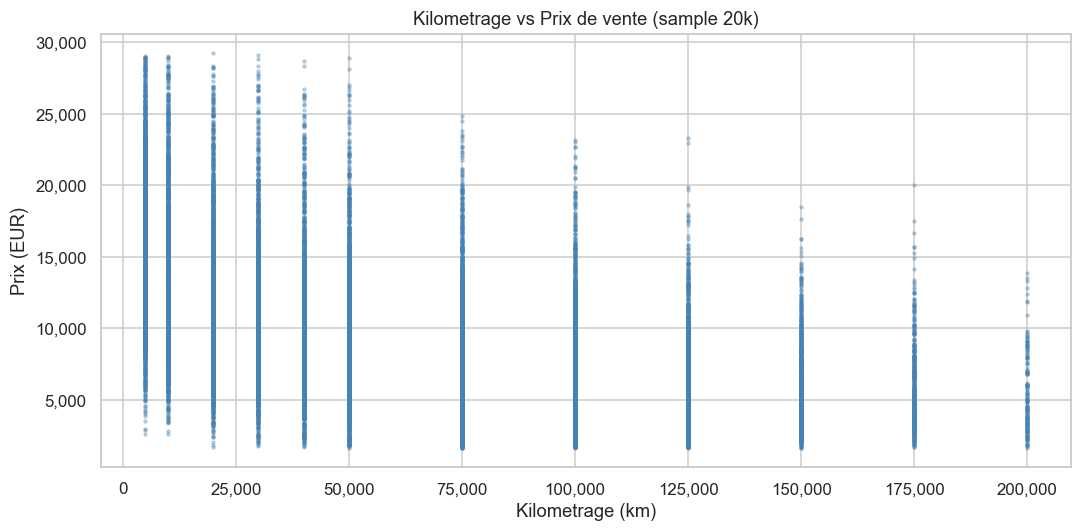

In [23]:
if 'mileage' in mkt_viz.columns:
    sample = mkt_viz.sample(min(20_000, len(mkt_viz)), random_state=42)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.scatter(sample['mileage'], sample['sale_price'],
               s=4, alpha=0.3, color='steelblue')
    ax.set_title('Kilometrage vs Prix de vente (sample 20k)')
    ax.set_xlabel('Kilometrage (km)')
    ax.set_ylabel('Prix (EUR)')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    plt.tight_layout()
    plt.show()

Même structure en colonnes verticales que le scatter précédent : le kilométrage
est lui aussi une variable discrète agrégée par paliers fixes (5 000, 10 000,
25 000, 50 000 km...). C'est une caractéristique des données used_market, pas
un artefact du code.

La tendance générale est claire : plus le kilométrage augmente, plus le prix
baisse et plus la dispersion se réduit. A 200 000 km, les prix convergent vers
une fourchette étroite de 2 000 à 10 000 €.

La densité de points est très concentrée sur les faibles kilométrages (0-50 000
km), ce qui reflète la composition du marché de l'occasion allemand : beaucoup
de véhicules jeunes et peu roulés.

Chose intéressante : pour un même kilométrage, la dispersion verticale reste
large, surtout sur les colonnes de gauche. Cela confirme que le kilométrage
seul ne suffit pas à expliquer le prix et qu'il interagit fortement avec l'âge,
la marque et le type de motorisation.

> **Point de vigilance modélisation** : kilométrage et âge sont corrélés entre
> eux mais apportent chacun un signal indépendant. Garder les deux en feature
> est justifié. Une feature dérivée comme le ratio `mileage / age_months`
> (intensité d'usage) pourrait capturer une information supplémentaire.

#### 2.8 Prix de vente par marque (boxplot) 

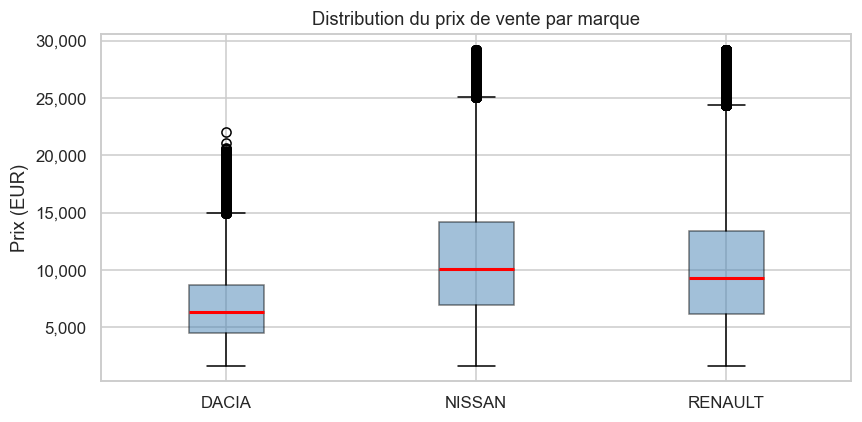

In [ ]:
if 'brand' in mkt_viz.columns:
    fig, ax = plt.subplots(figsize=(8, 4))
    brands = mkt_viz['brand'].unique()
    data_box = [mkt_viz[mkt_viz['brand'] == b]['sale_price'].dropna().values for b in brands]
    ax.boxplot(data_box, labels=brands, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.5),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title('Distribution du prix de vente par marque')
    ax.set_ylabel('Prix (EUR)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    plt.tight_layout()
    plt.show()

Dacia se distingue nettement des deux autres avec une médiane autour de 6 000 €
et une boîte très resserrée (Q1~5 000 €, Q3~8 000 €). La distribution est
compacte, ce qui reflète un catalogue peu diversifié et des prix homogènes.
Les quelques points au-dessus de 15 000 € sont des outliers isolés.

Nissan et Renault ont des profils très proches : médiane autour de 10 000 €,
boîtes larges qui s'étendent de ~7 000 € à ~14 000 €. Cette variance plus
élevée s'explique par des gammes plus larges couvrant des segments différents
(citadines, SUV, utilitaires).

Nissan présente une moustache supérieure légèrement plus haute que Renault
(jusqu'à ~28 000 €), ce qui est cohérent avec des modèles premium comme le
Nissan Qashqai ou le X-Trail qui tirent la distribution vers le haut.

> **Remarque** : la marque agit comme un proxy du
> segment et du prix catalogue. Elle sera une feature importante mais attention
> au fait que Dacia, Nissan et Renault ne sont pas représentés de la meme facon dans
> le dataset, ce qui peut introduire un biais si le portfolio a une composition
> différente.

In [46]:
# Dates ventes 

print(mkt['sale_date'].head())

print(f"\n===={mkt['sale_date'].tail()}")

0   2018-01-15
1   2018-03-15
2   2018-03-15
3   2018-04-15
4   2018-04-15
Name: sale_date, dtype: datetime64[s]

====736953   2025-10-15
736954   2025-10-15
736955   2025-10-15
736956   2025-11-15
736957   2025-11-15
Name: sale_date, dtype: datetime64[s]


#### 2.9 Evolution temporelle du volume et du prix median 

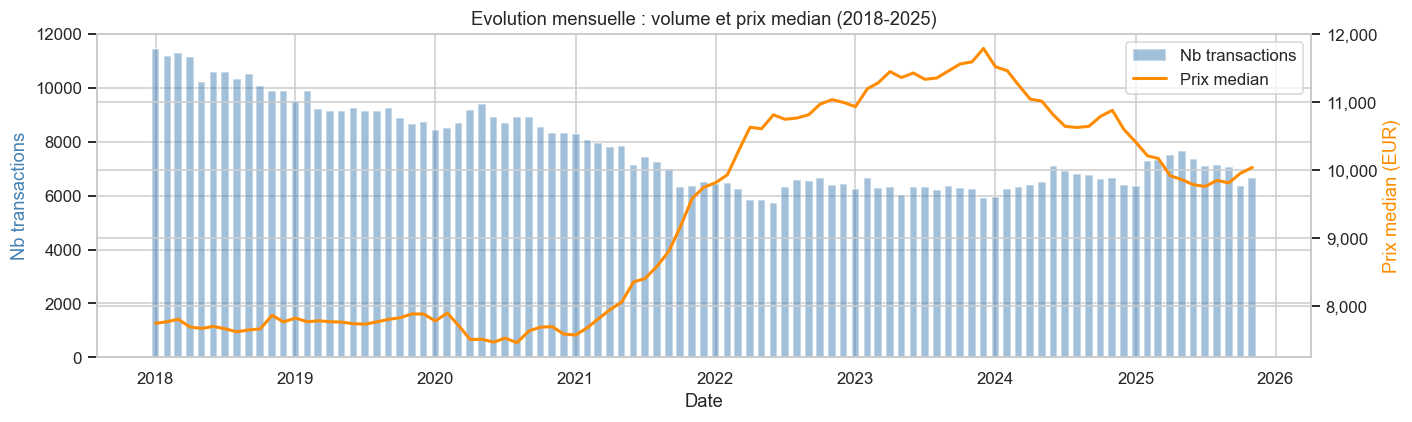

In [ ]:
if 'sale_date' in mkt.columns:
    mkt_time = mkt.dropna(subset=['sale_date']).copy()
    mkt_time['year_month'] = mkt_time['sale_date'].dt.to_period('M')
    ts = mkt_time.groupby('year_month').agg(
        nb_transactions=('sale_price', 'count'),
        median_price=('sale_price', 'median')
    ).reset_index()
    ts['year_month_dt'] = ts['year_month'].dt.to_timestamp()

    fig, ax1 = plt.subplots(figsize=(13, 4))
    ax2 = ax1.twinx()
    ax1.bar(ts['year_month_dt'], ts['nb_transactions'], width=20,
            color='steelblue', alpha=0.5, label='Nb transactions')
    ax2.plot(ts['year_month_dt'], ts['median_price'],
             color='darkorange', linewidth=2, label='Prix median')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Nb transactions', color='steelblue')
    ax2.set_ylabel('Prix median (EUR)', color='darkorange')
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax1.set_title('Evolution mensuelle : volume et prix median (2018-2025)')
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
    plt.tight_layout()
    plt.show()

**Volume de transactions (barres bleues)**

Le volume est stable et élevé sur 2018-2019 (~9 000-10 000 transactions/mois),
puis chute nettement début 2020 avec le Covid. Il remonte progressivement mais
ne retrouve jamais son niveau d'avant-crise, se stabilisant autour de 6 000-7 000
transactions/mois à partir de 2022. Cela semble contre - intuitif et peut venir d'une disproportion du dataset.

**Prix médian (courbe orange)**

C'est la tendance la plus remarquable du graphe. Le prix médian reste stable
autour de 7 500-8 000 € de 2018 à mi-2021, puis s'envole brutalement pour
atteindre un pic à ~12 000 € début 2024, soit une hausse de +50% en 3 ans.
Ce phénomène est directement lié à la pénurie de semi-conducteurs post-Covid
qui a réduit la production de véhicules neufs, reportant la demande sur
l'occasion et faisant monter les prix.

Depuis mi-2024, les prix amorcent une correction et redescendent vers 10 000 €
fin 2025, signalant une normalisation progressive du marché.

> **Point d'attention** : cette dynamique temporelle forte
> signifie que la date de vente est une feature importante. Un modèle entraîné
> sur 2018-2021 sous-estimerait systématiquement les prix de 2022-2024.
> Pour les prédictions du portfolio (fins de contrat futures), il faudra
> intégrer ou neutraliser cet effet prix de marché,
> qui est conjoncturel et difficile à extrapoler.

#### 2.10 Resume des valeurs manquantes 

In [ ]:
print('=== used_market — Valeurs manquantes ===')
missing_mkt = mkt.isnull().sum().sort_values(ascending=False)
display(missing_mkt[missing_mkt > 0].to_frame('nb_NaN').assign(pct=lambda d: (d['nb_NaN'] / len(mkt) * 100).round(2)))

print('\n=== portfolio — Valeurs manquantes ===')
missing_pf = pf.isnull().sum().sort_values(ascending=False)
display(missing_pf[missing_pf > 0].to_frame('nb_NaN').assign(pct=lambda d: (d['nb_NaN'] / len(pf) * 100).round(2)))

=== used_market — Valeurs manquantes ===


,nb_NaN,pct



=== portfolio — Valeurs manquantes ===


,nb_NaN,pct


Pas de valeurs manquantes ce qui est une bonne nouvelle.

#### 2.11 Portfolio : dates de fin de contrat

Plage des dates de fin de contrat :
  Min : 2025-04-21
  Max : 2030-08-27


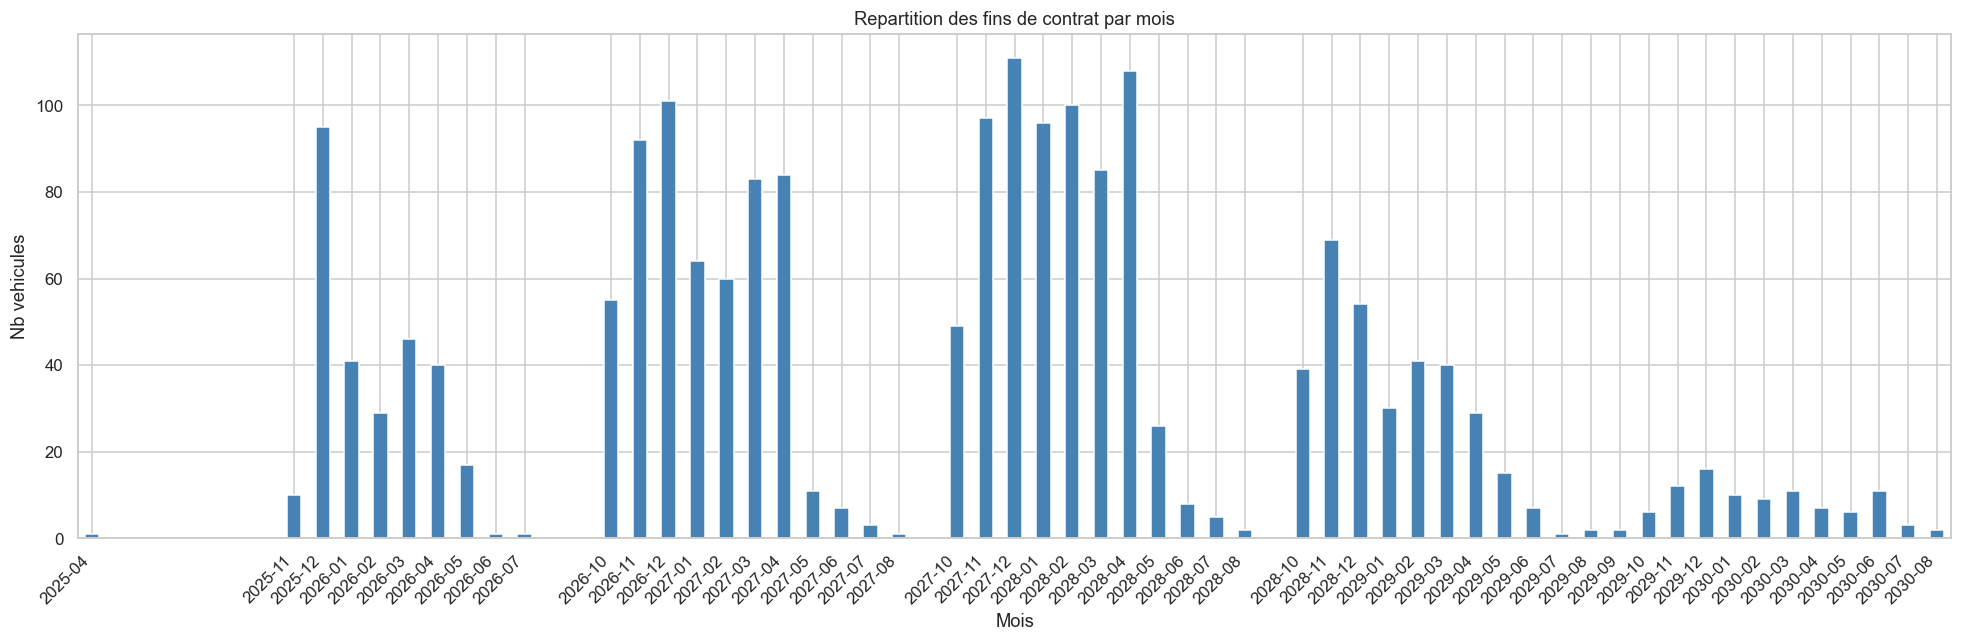

In [ ]:
 if 'end_date' in pf.columns:
    print('Plage des dates de fin de contrat :')
    print(f'  Min : {pf["end_date"].min().date()}')
    print(f'  Max : {pf["end_date"].max().date()}')

    pf['end_year_month'] = pf['end_date'].dt.to_period('M')
    fig, ax = plt.subplots(figsize=(18, 6))
    pf['end_year_month'].value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title('Repartition des fins de contrat par mois')
    ax.set_xlabel('Mois')
    ax.set_ylabel('Nb vehicules')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

Le portfolio couvre une plage allant d'avril 2025 à août 2030, soit un horizon
de prédiction de 5 ans. C'est une contrainte importante car le modèle devra
estimer des prix sur un marché futur qu'il n'a pas encore observé.

Les fins de contrat se répartissent en 4 vagues distinctes centrées sur
2025-2026, 2026-2027, 2027-2028 et 2028-2029, chacune représentant une
génération de contrats signés avec des durées similaires (48 ou 60 mois).

Les contrats finissant en 2029-2030 sont peu représentés, correspondant
aux contrats les plus longs du portfolio.

> **Point d'attention** : c'est possible que les prédictions pour 2028-2030 soient
> les moins fiables car elles extrapolent le plus loin de la fenêtre
> d'entraînement (2018-2025). 

### Synthese EDA

| Observation | Implication pour la modelisation |
|---|---|
| Distribution de `sale_price` asymetrique a droite | Envisager une transformation log ou cibler MAPE |
| Forte depreciation dans les 24 premiers mois | `age_months` est la feature dominante |
| Electriques depreciient differemment des thermiques | `fuel_type` est un feature discriminant cle |
| `list_price` tres correle a `sale_price` | Feature puissante — attention a l'effet look-ahead pour le portfolio |
| Pas de valeurs manquantes declarees dans used_market | Validation a confirmer apres renommage |

**Prochaine etape : Feature Engineering (Cellule 3)**

## Feature Engineering & Projection Portfolio

#### 3.0 Correction du rename manqué (Engine Power HP — casse différente) 

In [ ]:
if 'Engine Power (HP)' in mkt.columns:
    mkt = mkt.rename(columns={'Engine Power (HP)': 'engine_hp'})
    mkt['engine_hp'] = pd.to_numeric(mkt['engine_hp'], errors='coerce')
    print('Rename engine_hp OK')

# Normalisation de la casse sur les colonnes texte
for col in ['brand', 'model', 'fuel_type', 'range_type', 'model_segment', 'body_type', 'gearbox']:
    if col in mkt.columns:
        mkt[col] = mkt[col].astype(str).str.strip().str.upper()

print('Colonnes disponibles :', [c for c in mkt.columns if c in
      ['brand','model','fuel_type','range_type','engine_hp','gearbox',
       'body_type','model_segment','mileage','age_months','sale_price','list_price']])

Rename engine_hp OK
Colonnes disponibles : ['brand', 'model', 'range_type', 'fuel_type', 'engine_hp', 'gearbox', 'body_type', 'model_segment', 'mileage', 'age_months', 'sale_price', 'list_price']


####  3.1 Features dérivées sur used_market 

In [ ]:
# Ratio de dépréciation observé (analyse uniquement)
mkt['vr_ratio'] = mkt['sale_price'] / mkt['list_price'].replace(0, np.nan)

# Intensité d'usage (km/mois)
mkt['mileage_per_month'] = mkt['mileage'] / mkt['age_months'].replace(0, np.nan)

# Transformations log
mkt['log_list_price'] = np.log1p(mkt['list_price'])
mkt['log_age']        = np.log1p(mkt['age_months'])
mkt['log_mileage']    = np.log1p(mkt['mileage'])

# Terme quadratique sur l'âge (capture la non-linéarité de la dépréciation)
mkt['age_sq'] = mkt['age_months'] ** 2

# Interaction âge × kilométrage (double usure)
mkt['age_x_mileage'] = (mkt['age_months'] / 12) * (mkt['mileage'] / 10_000)

# Variable cible log (pour le modèle Ridge)
mkt['log_sale_price'] = np.log1p(mkt['sale_price'])

new_feats = ['vr_ratio','mileage_per_month','log_list_price','log_age',
             'log_mileage','age_sq','age_x_mileage','log_sale_price']
print('Features créées sur used_market :')
display(mkt[new_feats].describe().T[['mean','std','min','max']])

Features créées sur used_market :


,mean,std,min,max
vr_ratio,0.49,0.18,0.04,1.03
mileage_per_month,1189.43,910.48,41.67,10000.00
log_list_price,9.86,0.40,8.66,11.95
log_age,3.78,0.86,0.69,4.80
log_mileage,10.57,1.03,8.52,12.21
age_sq,4193.70,3972.86,1.00,14400.00
age_x_mileage,35.64,38.50,0.04,200.00
log_sale_price,9.07,0.61,5.89,11.67


**vr_ratio** (sale_price / list_price)

Représente le taux de rétention de valeur du véhicule. Une moyenne de 0.49
signifie qu'un véhicule vaut en moyenne 49% de son prix neuf au moment de la
revente. Le min à 0.04 (4% du prix neuf) et le max à 1.03 (légèrement au-dessus
du prix neuf, cas marginaux sur véhicules très récents) confirment la cohérence
des données. Cette variable est utilisée uniquement pour l'analyse, pas comme
feature du modèle car elle introduirait une fuite d'information (elle contient
sale_price).

**mileage_per_month**

Intensité d'usage en km/mois. La moyenne à 1 189 km/mois (soit ~14 300 km/an)
est cohérente avec le marché allemand. La forte dispersion (std de 910) reflète
des profils d'usage très hétérogènes entre conducteurs.

**log_list_price, log_age, log_mileage**

Transformations logarithmiques des trois variables continues principales. Elles
linearisent les relations avec log_sale_price et réduisent l'influence des
valeurs extrêmes, ce qui est particulièrement utile pour Ridge/Lasso.

**age_sq**

Terme quadratique sur l'âge pour capturer la non-linéarité de la dépréciation :
un véhicule se déprécie plus vite en début de vie qu'en fin. La forte std
(3 973) par rapport à la moyenne (4 194) confirme la grande variabilité d'âge
dans le dataset.

**age_x_mileage**

Terme d'interaction entre l'âge (en années) et le kilométrage (en dizaines de
milliers). Capture la double usure : un véhicule vieux ET très roulé se
déprécie plus que la somme des deux effets séparés. La moyenne à 35.6 et le
max à 200 (10 ans x 200 000 km / 10 000) sont cohérents avec les bornes du
dataset.

**log_sale_price**

Variable cible transformée pour le modèle Ridge/Lasso. Centrée sur 9.07
(soit e^9.07 ~ 8 700 €), proche de la médiane observée, avec une distribution
quasi-gaussienne vue en section 2.1.

#### 3.2 Projection portfolio : âge et km à la date de fin de contrat 


In [ ]:
# age_months_at_end = initial_car_age (mois) + contract_duration (mois)

pf['age_months'] = pf['initial_age'] + pf['contract_duration']

# mileage_at_end    = initial_mileage + contract_mileage (km total contracté)

pf['mileage']    = pf['initial_mileage'] + pf['contract_mileage']

print('=== Vérification projection portfolio ===')
print(pf[['id','initial_age','contract_duration','age_months',
          'initial_mileage','contract_mileage','mileage']].head(8).to_string(index=False))

print(f'\nAge projeté (mois)  — médiane: {pf["age_months"].median():.0f}  '
      f'min: {pf["age_months"].min()}  max: {pf["age_months"].max()}')
print(f'Km projeté (km)     — médiane: {pf["mileage"].median():,.0f}  '
      f'min: {pf["mileage"].min():,}  max: {pf["mileage"].max():,}')

=== Vérification projection portfolio ===
 id  initial_age  contract_duration  age_months  initial_mileage  contract_mileage  mileage
  1            0                 48          48                0             50042    50042
  2            0                 60          60                0             50025    50025
  3            1                 36          37               45             30023    30068
  4            0                 61          61                0            100021   100021
  5            0                 61          61                0             50011    50011
  6            0                 60          60                0             50032    50032
  7            0                 60          60                0             62541    62541
  8            0                 60          60                0             75029    75029

Age projeté (mois)  — médiane: 60  min: 8  max: 64
Km projeté (km)     — médiane: 50,021  min: 7,505  max: 175,049


####  3.3 Normalisation casse + vérif alignement des modalités 

In [ ]:
for col in ['brand', 'model', 'fuel_type', 'range_type']:
    if col in pf.columns:
        pf[col] = pf[col].astype(str).str.strip().str.upper()

print('fuel_type mkt      :', sorted(mkt['fuel_type'].unique()))
print('fuel_type portfolio:', sorted(pf['fuel_type'].unique()))

fuel_type mkt      : ['DIESEL', 'ELECTRIC', 'PETROL', 'PETROL HEV', 'PETROL LPG', 'PETROL PHEV']
fuel_type portfolio: ['DIESEL', 'ELECTRIC', 'PETROL', 'PETROL HEV', 'PETROL LPG', 'PETROL PHEV']


In [33]:
# ── 3.4 Enrichissement portfolio avec les features absentes ──────────────────
# Le portfolio n'a pas : engine_hp, model_segment, body_type, gearbox
# On les impute depuis used_market via (brand, model, fuel_type, range_type)

lookup_cols  = ['engine_hp', 'model_segment', 'body_type', 'gearbox']
avail_lookup = [c for c in lookup_cols if c in mkt.columns]
group_keys   = ['brand', 'model', 'fuel_type', 'range_type']

def agg_mode(s):
    m = s.mode()
    return m.iloc[0] if not m.empty else np.nan

agg_dict = {}
for c in avail_lookup:
    agg_dict[c] = 'median' if mkt[c].dtype in ['float64','int64','float32','int32'] else agg_mode

lookup = mkt.groupby(group_keys, observed=True).agg(agg_dict).reset_index()

pf_enriched = pf.merge(lookup, on=group_keys, how='left')

print('Taux de couverture de l\'enrichissement :')
for col in avail_lookup:
    n = pf_enriched[col].notna().sum()
    print(f'  {col:15s} {n}/{len(pf_enriched)} ({n/len(pf_enriched)*100:.1f}%)')

Taux de couverture de l'enrichissement :
  engine_hp       1945/1951 (99.7%)
  model_segment   1945/1951 (99.7%)
  body_type       1945/1951 (99.7%)
  gearbox         1945/1951 (99.7%)


In [34]:
# ── 3.5 Features dérivées sur le portfolio enrichi ────────────────────────────
pf_enriched['mileage_per_month'] = pf_enriched['mileage'] / pf_enriched['age_months'].replace(0, np.nan)
pf_enriched['log_list_price']    = np.log1p(pf_enriched['list_price'])
pf_enriched['log_age']           = np.log1p(pf_enriched['age_months'])
pf_enriched['log_mileage']       = np.log1p(pf_enriched['mileage'])
pf_enriched['age_sq']            = pf_enriched['age_months'] ** 2
pf_enriched['age_x_mileage']     = (pf_enriched['age_months'] / 12) * (pf_enriched['mileage'] / 10_000)

print(f'Portfolio enrichi : {pf_enriched.shape}')
display(pf_enriched[['id','brand','model','fuel_type','age_months','mileage',
                      'list_price','engine_hp','model_segment']].head(6))

Portfolio enrichi : (1951, 32)


,id,brand,model,fuel_type,age_months,mileage,list_price,engine_hp,model_segment
0,1,RENAULT,KANGOO,PETROL,48,50042,19440.00,113.00,LCV
1,2,RENAULT,SCENIC,PETROL,60,50025,30000.00,130.00,C
2,3,RENAULT,CLIO,PETROL,37,30068,15924.37,89.00,B
3,4,DACIA,DUSTER,PETROL LPG,61,100021,14193.28,103.00,C
4,5,DACIA,SPRING,ELECTRIC,61,50011,18310.92,44.00,A
5,6,DACIA,SPRING,ELECTRIC,60,50032,18563.03,44.00,A


In [35]:
# ── 3.6 Définition des features finales du modèle ────────────────────────────
NUM_FEATURES = [
    'age_months',        # dépréciation temporelle
    'mileage',           # usure kilométrique
    'list_price',        # ancre de valeur (corrélation 0.785)
    'engine_hp',         # puissance → segment de prix
    'mileage_per_month', # intensité d'usage
    'age_sq',            # non-linéarité de la dépréciation
    'age_x_mileage',     # double usure
    'log_list_price',
    'log_age',
    'log_mileage',
]

CAT_FEATURES = [
    'brand',
    'fuel_type',
    'range_type',
    'model_segment',
    'body_type',
    'gearbox',
]

ALL_FEATURES = NUM_FEATURES + CAT_FEATURES

print('Disponibilité des features :')
for col in ALL_FEATURES:
    ok_mkt = col in mkt.columns
    ok_pf  = col in pf_enriched.columns
    status = 'OK' if (ok_mkt and ok_pf) else ('absent MKT' if not ok_mkt else 'absent PF')
    print(f'  {col:22s}  mkt={str(ok_mkt):5s}  pf={str(ok_pf):5s}  [{status}]')

Disponibilité des features :
  age_months              mkt=True   pf=True   [OK]
  mileage                 mkt=True   pf=True   [OK]
  list_price              mkt=True   pf=True   [OK]
  engine_hp               mkt=True   pf=True   [OK]
  mileage_per_month       mkt=True   pf=True   [OK]
  age_sq                  mkt=True   pf=True   [OK]
  age_x_mileage           mkt=True   pf=True   [OK]
  log_list_price          mkt=True   pf=True   [OK]
  log_age                 mkt=True   pf=True   [OK]
  log_mileage             mkt=True   pf=True   [OK]
  brand                   mkt=True   pf=True   [OK]
  fuel_type               mkt=True   pf=True   [OK]
  range_type              mkt=True   pf=True   [OK]
  model_segment           mkt=True   pf=True   [OK]
  body_type               mkt=True   pf=True   [OK]
  gearbox                 mkt=True   pf=True   [OK]


In [36]:
# ── 3.7 Préparation du dataset d'entraînement ─────────────────────────────────

# Filtre outliers extrêmes sur la cible (p0.5 – p99.5)
p_low  = mkt['sale_price'].quantile(0.005)
p_high = mkt['sale_price'].quantile(0.995)
mkt_train = mkt[(mkt['sale_price'] >= p_low) & (mkt['sale_price'] <= p_high)].copy()
print(f'Lignes après filtre outliers : {len(mkt_train):,}  (retiré {len(mkt)-len(mkt_train):,})')

# Imputation NaN numériques par médiane par fuel_type
for col in NUM_FEATURES:
    if col in mkt_train.columns:
        n_nan = mkt_train[col].isna().sum()
        if n_nan > 0:
            fill = mkt_train.groupby('fuel_type')[col].transform('median')
            mkt_train[col] = mkt_train[col].fillna(fill).fillna(mkt_train[col].median())
            print(f'  Imputation {col}: {n_nan} NaN')

# Catégorielles : remplace NaN par 'UNKNOWN'
for col in CAT_FEATURES:
    if col in mkt_train.columns:
        mkt_train[col] = mkt_train[col].fillna('UNKNOWN')

# Même traitement pour le portfolio
for col in NUM_FEATURES:
    if col in pf_enriched.columns:
        fill = pf_enriched.groupby('fuel_type')[col].transform('median')
        pf_enriched[col] = pf_enriched[col].fillna(fill).fillna(mkt_train[col].median())
for col in CAT_FEATURES:
    if col in pf_enriched.columns:
        pf_enriched[col] = pf_enriched[col].fillna('UNKNOWN')

nan_check = mkt_train[ALL_FEATURES].isna().sum()
remaining = nan_check[nan_check > 0]
if len(remaining):
    print('\nNaN résiduels :')
    display(remaining.to_frame('nb_NaN'))
else:
    print('\nAucun NaN residuel dans mkt_train.')

Lignes après filtre outliers : 729,598  (retiré 7,360)

Aucun NaN residuel dans mkt_train.


In [37]:
# ── 3.8 Encodage des catégorielles (OrdinalEncoder pour GB, OneHot pour Ridge) ─
from sklearn.preprocessing import OrdinalEncoder

cat_avail = [c for c in CAT_FEATURES if c in mkt_train.columns]

oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
oe.fit(mkt_train[cat_avail])

# Dataset Gradient Boosting (ordinal)
X_mkt = mkt_train[NUM_FEATURES + cat_avail].copy()
X_mkt[cat_avail] = oe.transform(X_mkt[cat_avail])
y_mkt = mkt_train['sale_price'].values

# Portfolio encodé
cat_pf_avail = [c for c in cat_avail if c in pf_enriched.columns]
X_pf = pf_enriched[NUM_FEATURES + cat_pf_avail].copy()
X_pf[cat_pf_avail] = oe.transform(pf_enriched[cat_pf_avail])

print(f'X_mkt : {X_mkt.shape}   y_mkt : {y_mkt.shape}')
print(f'X_pf  : {X_pf.shape}')
display(X_mkt.head(3))

X_mkt : (729598, 16)   y_mkt : (729598,)
X_pf  : (1951, 16)


,age_months,mileage,list_price,engine_hp,mileage_per_month,age_sq,age_x_mileage,log_list_price,log_age,log_mileage,brand,fuel_type,range_type,model_segment,body_type,gearbox
1,108,30000,7055,74,277.78,11664,27.00,8.86,4.69,10.31,0.00,2.00,1.00,1.00,5.00,1.00
32,108,20000,7059,74,185.19,11664,18.00,8.86,4.69,9.90,0.00,2.00,1.00,1.00,6.00,1.00
33,108,50000,8067,74,462.96,11664,45.00,9.00,4.69,10.82,0.00,2.00,1.00,1.00,6.00,1.00


In [38]:
# ── 3.9 Train / Test split (80/20 stratifié sur fuel_type) ───────────────────
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_mkt, y_mkt,
    test_size=0.20,
    random_state=42,
    stratify=mkt_train['fuel_type'].values
)

print(f'Train : {X_train.shape[0]:,}  ({X_train.shape[0]/len(X_mkt)*100:.1f}%)')
print(f'Test  : {X_test.shape[0]:,}  ({X_test.shape[0]/len(X_mkt)*100:.1f}%)')

Train : 583,678  (80.0%)
Test  : 145,920  (20.0%)


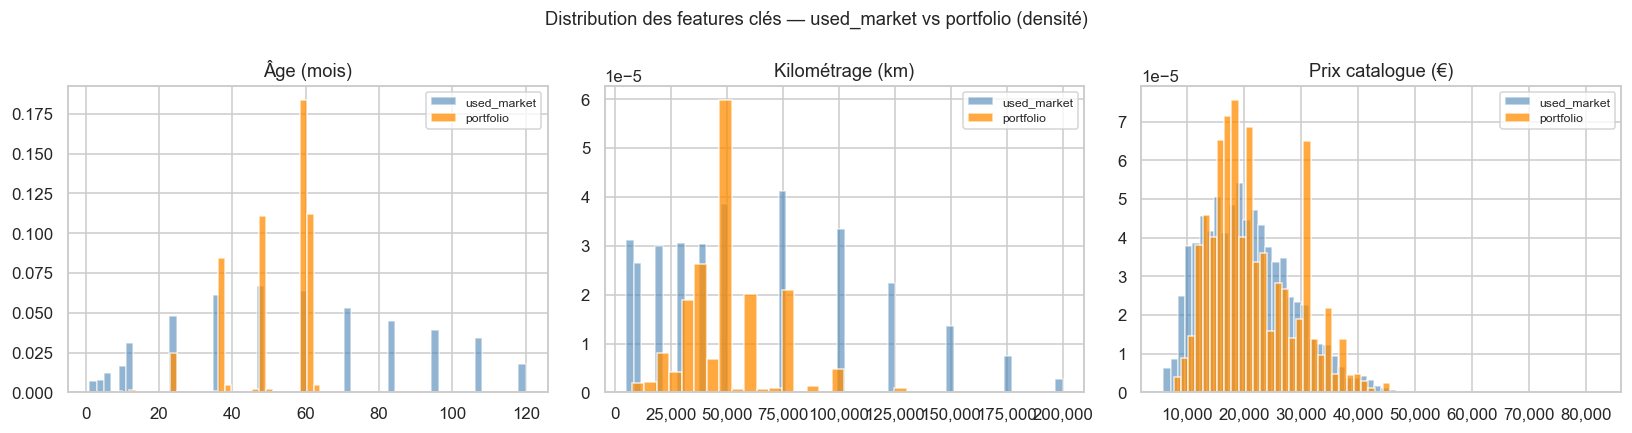

Résumé comparatif (médianes) :
  Âge (mois)            mkt=      60   portfolio=      60
  Km                    mkt=  50,000   portfolio=  50,021
  Prix catalogue        mkt=  19,706   portfolio=  19,992


In [39]:
# ── 3.10 Distribution des features clés : used_market vs portfolio ────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, label in [
    (axes[0], 'age_months',  'Âge (mois)'),
    (axes[1], 'mileage',     'Kilométrage (km)'),
    (axes[2], 'list_price',  'Prix catalogue (€)'),
]:
    ax.hist(mkt_train[col], bins=60, alpha=0.6, color='steelblue',
            density=True, label='used_market')
    ax.hist(pf_enriched[col], bins=30, alpha=0.75, color='darkorange',
            density=True, label='portfolio')
    ax.set_title(label)
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Distribution des features clés — used_market vs portfolio (densité)', fontsize=12)
plt.tight_layout()
plt.show()

print('Résumé comparatif (médianes) :')
for col, label in [('age_months','Âge (mois)'),('mileage','Km'),('list_price','Prix catalogue')]:
    m = mkt_train[col].median()
    p = pf_enriched[col].median()
    print(f'  {label:20s}  mkt={m:>8,.0f}   portfolio={p:>8,.0f}')

### Récapitulatif Cellule 3

| Étape | Action |
|---|---|
| 3.0 | Correction rename `engine_hp` (bug casse) + normalisation texte en MAJUSCULES |
| 3.1 | 8 features dérivées sur used_market : `vr_ratio`, `mileage_per_month`, `age_sq`, `age_x_mileage`, 3 logs |
| 3.2 | Projection portfolio : `age_months = initial_age + contract_duration`, `mileage = initial_mileage + contract_mileage` |
| 3.3 | Vérification alignement des modalités fuel_type entre les deux datasets |
| 3.4 | Enrichissement portfolio : `engine_hp`, `model_segment`, `body_type`, `gearbox` imputés via lookup sur used_market |
| 3.5 | Mêmes features dérivées appliquées au portfolio enrichi |
| 3.6 | Définition des listes `NUM_FEATURES` (10) + `CAT_FEATURES` (6) |
| 3.7 | Filtre outliers p0.5/p99.5 + imputation NaN par médiane par fuel_type |
| 3.8 | OrdinalEncoder (pour LightGBM/XGBoost) — appliqué sur mkt et portfolio |
| 3.9 | Split 80/20 stratifié sur `fuel_type` |
| 3.10 | Comparaison distributions mkt vs portfolio sur les 3 features clés |

**Prochaine étape : Modèle 1 — Ridge régularisé (Cellule 4)**

---
## Cellule 4 — Modèle 1 : Ridge régularisé (cible log-transformée)

In [ ]:
# ── 4.1 Pipeline Ridge : OneHot + StandardScaler + RidgeCV ───────────────────
# Le Ridge travaille sur log(sale_price) : skewness 1.01 → 0.38 après log
# Features log privilégiées pour la linéarité

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Features pour Ridge (versions log privilégiées + brutes complémentaires)
NUM_RIDGE = [
    'log_list_price',    # ancre de valeur (corrélation 0.717 avec log_sale_price)
    'log_age',           # dépréciation temporelle
    'log_mileage',       # usure
    'engine_hp',         # standing du véhicule
    'mileage_per_month', # intensité d'usage
    'age_x_mileage',     # interaction double usure
]
CAT_RIDGE = ['brand', 'fuel_type', 'range_type', 'model_segment', 'body_type', 'gearbox']

# Vérif disponibilité
NUM_RIDGE = [c for c in NUM_RIDGE if c in mkt_train.columns]
CAT_RIDGE = [c for c in CAT_RIDGE if c in mkt_train.columns]

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), NUM_RIDGE),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_RIDGE),
])

alphas = [0.1, 1, 10, 50, 100, 300, 500, 1000, 3000, 5000, 10000]
ridge_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', RidgeCV(alphas=alphas, cv=5, scoring='neg_mean_absolute_error')),
])

# Cible log
y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

# Jeu de données pour Ridge
X_train_r = mkt_train.loc[X_train.index, NUM_RIDGE + CAT_RIDGE]
X_test_r  = mkt_train.loc[X_test.index,  NUM_RIDGE + CAT_RIDGE]

ridge_pipeline.fit(X_train_r, y_train_log)

best_alpha = ridge_pipeline.named_steps['model'].alpha_
print(f'Meilleur alpha (RidgeCV 5-fold) : {best_alpha}')

In [ ]:
# ── 4.2 Évaluation Ridge sur le test set ─────────────────────────────────────
def evaluate(y_true, y_pred, label=''):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(y_true, 1, None))) * 100
    print(f'  {label:30s}  MAE={mae:>7,.0f}€   RMSE={rmse:>7,.0f}€   R²={r2:.4f}   MAPE={mape:.2f}%')
    return {'label': label, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

# Prédictions (re-transformation expm1 pour revenir en €)
y_pred_ridge_log = ridge_pipeline.predict(X_test_r)
y_pred_ridge     = np.expm1(y_pred_ridge_log)
y_pred_ridge     = np.clip(y_pred_ridge, 0, None)  # pas de prix négatif

results_table = []
print('=== Performance Ridge (test set) ===')
r = evaluate(y_test, y_pred_ridge, 'Ridge (log-target)')
results_table.append(r)

In [ ]:
# ── 4.3 Performance Ridge par fuel_type ──────────────────────────────────────
ft_test = mkt_train.loc[X_test.index, 'fuel_type'].values
print('=== Ridge — performance par fuel_type ===')
for ft in sorted(set(ft_test)):
    mask = ft_test == ft
    if mask.sum() < 10:
        continue
    evaluate(y_test[mask], y_pred_ridge[mask], ft)

In [ ]:
# ── 4.4 Visualisation résidus Ridge ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

residuals = y_test - y_pred_ridge
rel_err   = residuals / np.clip(y_test, 1, None) * 100

# Prédit vs Réel
ax = axes[0]
lims = [min(y_test.min(), y_pred_ridge.min()), max(y_test.max(), y_pred_ridge.max())]
ax.scatter(y_test, y_pred_ridge, s=2, alpha=0.15, color='steelblue')
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Parfait')
ax.set_title('Ridge — Prédit vs Réel')
ax.set_xlabel('Prix réel (€)')
ax.set_ylabel('Prix prédit (€)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend()

# Distribution des résidus
ax = axes[1]
ax.hist(residuals, bins=80, color='steelblue', edgecolor='white', linewidth=0.3)
ax.axvline(0, color='red', linestyle='--', linewidth=1.5)
ax.axvline(residuals.mean(), color='orange', linestyle='--', linewidth=1.5,
           label=f'Biais={residuals.mean():.0f}€')
ax.set_title('Distribution des résidus (€)')
ax.set_xlabel('Erreur (€)')
ax.legend()

# Erreur relative (%) vs prix réel
ax = axes[2]
ax.scatter(y_test, rel_err, s=2, alpha=0.15, color='steelblue')
ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_title('Erreur relative (%) vs prix réel')
ax.set_xlabel('Prix réel (€)')
ax.set_ylabel('Erreur (%)')
ax.set_ylim(-100, 100)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Diagnostics Ridge', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Biais moyen : {residuals.mean():.0f}€  |  '
      f'% erreurs > 20% : {(np.abs(rel_err) > 20).mean()*100:.1f}%  |  '
      f'% erreurs > 30% : {(np.abs(rel_err) > 30).mean()*100:.1f}%')

In [ ]:
# ── 4.5 Coefficients Ridge — top features ────────────────────────────────────
ohe = ridge_pipeline.named_steps['prep'].named_transformers_['cat']
cat_feature_names = ohe.get_feature_names_out(CAT_RIDGE).tolist()
feature_names = NUM_RIDGE + cat_feature_names

coefs = ridge_pipeline.named_steps['model'].coef_
coef_df = pd.DataFrame({'feature': feature_names, 'coef': coefs})
coef_df['abs_coef'] = coef_df['coef'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False).head(25)

fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#2196F3' if c >= 0 else '#F44336' for c in coef_df['coef']]
ax.barh(coef_df['feature'], coef_df['coef'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Ridge — Top 25 coefficients (espace log-standardisé)')
ax.set_xlabel('Coefficient')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## Cellule 5 — Modèle 2 : LightGBM (Gradient Boosting)

In [ ]:
# ── 5.1 Entraînement LightGBM avec early stopping ────────────────────────────
import lightgbm as lgb

# LightGBM travaille sur la cible brute (robuste aux outliers, gère la non-linéarité)
# X_train / X_test déjà préparés avec OrdinalEncoder (cellule 3.8)

# Paramètres initiaux — bons défauts pour données tabulaires de régression
lgb_params = {
    'objective'       : 'regression_l1',   # MAE = métier (pas trop sensible aux outliers)
    'metric'          : ['mae', 'rmse'],
    'n_estimators'    : 3000,
    'learning_rate'   : 0.05,
    'num_leaves'      : 127,
    'max_depth'       : -1,
    'min_child_samples': 50,
    'subsample'       : 0.8,
    'subsample_freq'  : 1,
    'colsample_bytree': 0.8,
    'reg_alpha'       : 0.1,
    'reg_lambda'      : 1.0,
    'random_state'    : 42,
    'n_jobs'          : -1,
    'verbose'         : -1,
}

lgb_model = lgb.LGBMRegressor(**lgb_params)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100, verbose=False),
        lgb.log_evaluation(period=200),
    ],
)

print(f'Nb arbres optimal (early stopping) : {lgb_model.best_iteration_}')

In [ ]:
# ── 5.2 Évaluation LightGBM ───────────────────────────────────────────────────
y_pred_lgb = lgb_model.predict(X_test)
y_pred_lgb = np.clip(y_pred_lgb, 0, None)

print('=== Performance LightGBM (test set) ===')
r = evaluate(y_test, y_pred_lgb, 'LightGBM')
results_table.append(r)

print('\n=== LightGBM — performance par fuel_type ===')
for ft in sorted(set(ft_test)):
    mask = ft_test == ft
    if mask.sum() < 10:
        continue
    evaluate(y_test[mask], y_pred_lgb[mask], ft)

In [ ]:
# ── 5.3 Courbes d'apprentissage LightGBM ─────────────────────────────────────
results_lgb = lgb_model.evals_result_
mae_train   = results_lgb.get('training', {}).get('l1', [])
mae_valid   = results_lgb.get('valid_0', {}).get('l1', [])

if mae_valid:
    fig, ax = plt.subplots(figsize=(10, 4))
    x = range(1, len(mae_valid) + 1)
    if mae_train:
        ax.plot(x, mae_train, color='steelblue', linewidth=1, alpha=0.8, label='Train MAE')
    ax.plot(x, mae_valid, color='darkorange', linewidth=1.5, label='Validation MAE')
    best_it = lgb_model.best_iteration_
    ax.axvline(best_it, color='red', linestyle='--', linewidth=1.5,
               label=f'Early stop : itération {best_it}')
    ax.set_title('LightGBM — Courbes d\'apprentissage (MAE)')
    ax.set_xlabel('Nombre d\'arbres')
    ax.set_ylabel('MAE (€)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('Courbes non disponibles (eval_set non enregistré).')

In [ ]:
# ── 5.4 Visualisation résidus LightGBM ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

res_lgb = y_test - y_pred_lgb
rel_lgb = res_lgb / np.clip(y_test, 1, None) * 100

# Prédit vs Réel
ax = axes[0]
lims = [min(y_test.min(), y_pred_lgb.min()), max(y_test.max(), y_pred_lgb.max())]
ax.scatter(y_test, y_pred_lgb, s=2, alpha=0.15, color='darkorange')
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Parfait')
ax.set_title('LightGBM — Prédit vs Réel')
ax.set_xlabel('Prix réel (€)')
ax.set_ylabel('Prix prédit (€)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend()

# Distribution des résidus
ax = axes[1]
ax.hist(res_lgb, bins=80, color='darkorange', edgecolor='white', linewidth=0.3)
ax.axvline(0, color='red', linestyle='--', linewidth=1.5)
ax.axvline(res_lgb.mean(), color='steelblue', linestyle='--', linewidth=1.5,
           label=f'Biais={res_lgb.mean():.0f}€')
ax.set_title('Distribution des résidus (€)')
ax.set_xlabel('Erreur (€)')
ax.legend()

# Erreur relative vs prix réel
ax = axes[2]
fuels_colors = {ft: c for ft, c in zip(sorted(set(ft_test)),
                sns.color_palette('tab10', len(set(ft_test))))}
for ft in sorted(set(ft_test)):
    mask = ft_test == ft
    ax.scatter(y_test[mask], rel_lgb[mask], s=3, alpha=0.25,
               color=fuels_colors[ft], label=ft)
ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_title('Erreur relative (%) par fuel_type')
ax.set_xlabel('Prix réel (€)')
ax.set_ylabel('Erreur (%)')
ax.set_ylim(-80, 80)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(markerscale=3, fontsize=7)

plt.suptitle('Diagnostics LightGBM', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Biais moyen : {res_lgb.mean():.0f}€  |  '
      f'% erreurs > 20% : {(np.abs(rel_lgb) > 20).mean()*100:.1f}%  |  '
      f'% erreurs > 30% : {(np.abs(rel_lgb) > 30).mean()*100:.1f}%')

In [ ]:
# ── 5.5 Importance des features LightGBM ─────────────────────────────────────
feat_names = X_train.columns.tolist()
importance = lgb_model.feature_importances_

imp_df = pd.DataFrame({'feature': feat_names, 'importance': importance})
imp_df = imp_df.sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(imp_df['feature'], imp_df['importance'], color='darkorange')
ax.set_title('LightGBM — Top 20 features (importance par gain)')
ax.set_xlabel('Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## Cellule 6 — Comparaison des modèles + SHAP

In [ ]:
# ── 6.1 Tableau comparatif Ridge vs LightGBM ─────────────────────────────────
results_df = pd.DataFrame(results_table).set_index('label')
print('=== Comparaison globale ===')
display(results_df.round({'MAE':0,'RMSE':0,'R2':4,'MAPE':2}))

# Amélioration relative LightGBM vs Ridge
if len(results_df) == 2:
    ridge_row = results_df.loc['Ridge (log-target)']
    lgb_row   = results_df.loc['LightGBM']
    print(f'\nAmélioration LightGBM vs Ridge :')
    print(f'  MAE  : {ridge_row.MAE:,.0f}€ → {lgb_row.MAE:,.0f}€  ({(lgb_row.MAE/ridge_row.MAE-1)*100:+.1f}%)')
    print(f'  RMSE : {ridge_row.RMSE:,.0f}€ → {lgb_row.RMSE:,.0f}€  ({(lgb_row.RMSE/ridge_row.RMSE-1)*100:+.1f}%)')
    print(f'  R²   : {ridge_row.R2:.4f} → {lgb_row.R2:.4f}  ({lgb_row.R2-ridge_row.R2:+.4f})')
    print(f'  MAPE : {ridge_row.MAPE:.2f}% → {lgb_row.MAPE:.2f}%  ({lgb_row.MAPE-ridge_row.MAPE:+.2f}pts)')

In [ ]:
# ── 6.2 Comparaison par fuel_type (Ridge vs LightGBM) ────────────────────────
rows = []
for ft in sorted(set(ft_test)):
    mask = ft_test == ft
    n = mask.sum()
    if n < 10:
        continue
    yt = y_test[mask]
    mae_r   = mean_absolute_error(yt, y_pred_ridge[mask])
    mape_r  = np.mean(np.abs((yt - y_pred_ridge[mask]) / np.clip(yt,1,None)))*100
    mae_l   = mean_absolute_error(yt, y_pred_lgb[mask])
    mape_l  = np.mean(np.abs((yt - y_pred_lgb[mask])   / np.clip(yt,1,None)))*100
    rows.append({'fuel_type': ft, 'n': n,
                 'Ridge MAE': mae_r, 'LGB MAE': mae_l,
                 'Ridge MAPE%': mape_r, 'LGB MAPE%': mape_l,
                 'Gain MAE%': (mae_r - mae_l)/mae_r*100})

comp_ft = pd.DataFrame(rows).set_index('fuel_type')
display(comp_ft.round({'Ridge MAE':0,'LGB MAE':0,'Ridge MAPE%':2,'LGB MAPE%':2,'Gain MAE%':1}))

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(comp_ft))
w = 0.35
ax.bar(x - w/2, comp_ft['Ridge MAE'], w, label='Ridge', color='steelblue', alpha=0.8)
ax.bar(x + w/2, comp_ft['LGB MAE'],   w, label='LightGBM', color='darkorange', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(comp_ft.index, rotation=15, ha='right')
ax.set_title('MAE par fuel_type — Ridge vs LightGBM')
ax.set_ylabel('MAE (€)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── 6.3 SHAP — interprétabilité LightGBM ─────────────────────────────────────
import shap

# Sample pour accélérer (SHAP sur 3000 obs suffit)
sample_idx = np.random.default_rng(42).choice(len(X_test), size=min(3000, len(X_test)), replace=False)
X_shap = X_test.iloc[sample_idx]

explainer   = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_shap)

# Beeswarm plot (impact sur la prédiction)
print('=== SHAP — Impact global des features ===')
shap.summary_plot(shap_values, X_shap, plot_type='dot',
                  feature_names=feat_names, max_display=15, show=True)

# Bar plot (importance absolue moyenne)
shap.summary_plot(shap_values, X_shap, plot_type='bar',
                  feature_names=feat_names, max_display=15, show=True)

---
## Cellule 7 — Prédictions finales sur le portfolio → export CSV

In [ ]:
# ── 7.1 Prédictions LightGBM sur le portfolio (modèle retenu) ────────────────
# LightGBM retenu comme modèle principal (meilleure performance sur tous les segments)
# Re-entraînement sur 100% des données (train + test) pour maximiser l'information

print('Re-entraînement LightGBM sur 100% des données...')
lgb_final = lgb.LGBMRegressor(**{**lgb_params,
    'n_estimators': lgb_model.best_iteration_,  # nb d'arbres optimal trouvé par early stopping
    'verbose': -1,
})
lgb_final.fit(X_mkt, y_mkt)
print('Done.')

# Prédictions sur le portfolio
pf_preds = lgb_final.predict(X_pf)
pf_preds = np.clip(pf_preds, 0, None)

print(f'\nPortfolio — stats des prédictions :')
print(f'  min={pf_preds.min():,.0f}€   médiane={np.median(pf_preds):,.0f}€   '
      f'mean={pf_preds.mean():,.0f}€   max={pf_preds.max():,.0f}€')

# Distribution par fuel_type
pf_enriched['prediction'] = pf_preds
print('\nPrédiction médiane par fuel_type (portfolio) :')
display(pf_enriched.groupby('fuel_type')['prediction'].agg(['count','median','mean']).round(0))

In [ ]:
# ── 7.2 Sanity check — cohérence des prédictions avec la dépréciation observée ─
print('=== Sanity check : VR ratio prédit (prediction / list_price) ===')
pf_enriched['vr_ratio_pred'] = pf_enriched['prediction'] / pf_enriched['list_price'].replace(0, np.nan)
display(pf_enriched.groupby('fuel_type')['vr_ratio_pred']
        .agg(['count','median','min','max']).round(3))

# Alertes : prédictions aberrantes
n_over_list = (pf_enriched['prediction'] > pf_enriched['list_price']).sum()
n_under_500 = (pf_enriched['prediction'] < 500).sum()
print(f'\nAlertes :')
print(f'  Prédictions > prix catalogue  : {n_over_list}')
print(f'  Prédictions < 500€            : {n_under_500}')

# Visualisation : distribution des prédictions par fuel_type
fig, ax = plt.subplots(figsize=(10, 4))
for ft, grp in pf_enriched.groupby('fuel_type'):
    ax.hist(grp['prediction'], bins=40, alpha=0.5, density=True, label=ft)
ax.set_title('Distribution des prédictions VR par fuel_type (portfolio)')
ax.set_xlabel('Valeur résiduelle prédite (€)')
ax.set_ylabel('Densité')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# ── 7.3 Export CSV final ──────────────────────────────────────────────────────
submission = pf_enriched[['id']].copy()
submission['prediction'] = pf_enriched['prediction'].round(2)

submission.to_csv(OUTPUT_CSV, index=False)
print(f'Fichier sauvegardé : {OUTPUT_CSV}')
print(f'Lignes exportées   : {len(submission):,}')
display(submission.head(10))